## Task 5: Linear Model for Mileage

Create a linear regression model from `Fahrzeuge_OEM1_Typ11_Fehleranalyse.csv` to predict the mileage at failure (`Fehlerhaft_Fahrleistung`) based on suitable variables. The dataset contains only vehicles with defects (198,069 entries).

**Feature selection:**
- `days`: vehicle age in days at time of failure
- `fuel`: fuel consumption
- `engine`: engine size (small, medium, large), one-hot encoded with `drop='first'` (reference category: large)

Excluded: `ID_Fahrzeug` (unique identifier), `Herstellernummer` (constant value 1), `Werksnummer` (only 2 values, low predictive value), `Fehlerhaft_Datum` (only known after failure, not a predictor).

Importing and overviewing the data

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Importing the csv-file
data = pd.read_csv('data/Fahrzeug/Fahrzeuge_OEM1_Typ11_Fehleranalyse.csv')

# Data overview
display(data.head())
display(data.info())
print(f"All {len(data)} entries have Fehlerhaft_Fahrleistung > 0")

,Unnamed: 0,X,X1,ID_Fahrzeug,Herstellernummer,Werksnummer,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung,days,fuel,engine
0,9,9,9,11-1-11-9,1,11,2010-03-16,34824.319559,1493.150761,4.003670,small
1,11,11,11,11-1-11-11,1,11,2010-03-16,74217.428309,1044.462231,11.042487,large
2,13,13,13,11-1-11-13,1,11,2010-03-16,32230.699639,749.669810,3.579117,small
3,15,15,15,11-1-11-15,1,11,2010-03-16,44885.783551,858.688003,4.666801,small
4,37,37,37,11-1-11-37,1,11,2010-03-17,86348.329866,1478.204174,4.634381,small


<class 'pandas.DataFrame'>
RangeIndex: 198069 entries, 0 to 198068
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               198069 non-null  int64  
 1   X                        198069 non-null  int64  
 2   X1                       198069 non-null  int64  
 3   ID_Fahrzeug              198069 non-null  str    
 4   Herstellernummer         198069 non-null  int64  
 5   Werksnummer              198069 non-null  int64  
 6   Fehlerhaft_Datum         198069 non-null  str    
 7   Fehlerhaft_Fahrleistung  198069 non-null  float64
 8   days                     198069 non-null  float64
 9   fuel                     198069 non-null  float64
 10  engine                   198069 non-null  str    
dtypes: float64(3), int64(5), str(3)
memory usage: 22.1 MB


None

All 198069 entries have Fehlerhaft_Fahrleistung > 0


The data is split into 70% training and 30% test set using `train_test_split` with a fixed `random_state` for reproducibility.

In [ ]:
# defining feature- and targetvector

X = data[['days', 'fuel', 'engine']]

y = data['Fehlerhaft_Fahrleistung']

# Creating a Train-Test-Split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

The `engine` column contains categorical values (`small`, `medium`, `large`) and needs to be one-hot encoded. `drop='first'` removes the `large` category as the reference. The encoded columns are then combined with the numeric features `days` and `fuel` into the final feature arrays.

In [ ]:
# One Hot Encoding the engine
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoder.fit(x_train[['engine']])

encoded_engine_train = encoder.transform(x_train[['engine']])
encoded_engine_test = encoder.transform(x_test[['engine']])

# Combine numeric features with encoded engine columns
X_train = np.column_stack([x_train['days'].to_numpy(), 
                   x_train['fuel'].to_numpy(), encoded_engine_train]) # type: ignore

X_test = np.column_stack([x_test['days'].to_numpy(), 
                   x_test['fuel'].to_numpy(), encoded_engine_test]) # type: ignore

A `LinearRegression` model from scikit-learn is trained on the encoded feature set. The model is evaluated using 5-fold cross-validation on the training data and then tested on the held-out test set using the R² score.

In [17]:
print("Feature Names:", encoder.get_feature_names_out())

# Train the model
model = LinearRegression()
model.fit(X=X_train, y=y_train)

# Calculate the evaluation scores
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("R² mean: %0.4f (std: %0.4f)" % (scores.mean(), scores.std()))

# Calculate the R² Score
y_pred = model.predict(X_test)
print(f"R² score (test set): {r2_score(y_test, y_pred):.4f}")

Feature Names: ['engine_medium' 'engine_small']
R² mean: 0.4827 (std: 0.0037)
R² score (test set): 0.4862


The model coefficients show the effect of each feature on the predicted mileage at failure. The intercept represents the baseline for a vehicle with a large engine.

In [ ]:
feature_names = ['days', 'fuel'] + list(encoder.get_feature_names_out())

# Calculating the coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_})

print(f"Intercept: {model.intercept_:.2f}")
display(coef_df)

Intercept: 9904.54


,Feature,Coefficient
0,days,-0.175037
1,fuel,5218.744921
2,engine_medium,7749.400361
3,engine_small,11054.006603


The predicted vs. actual scatter plot visualizes the model fit. Points close to the red diagonal indicate accurate predictions.

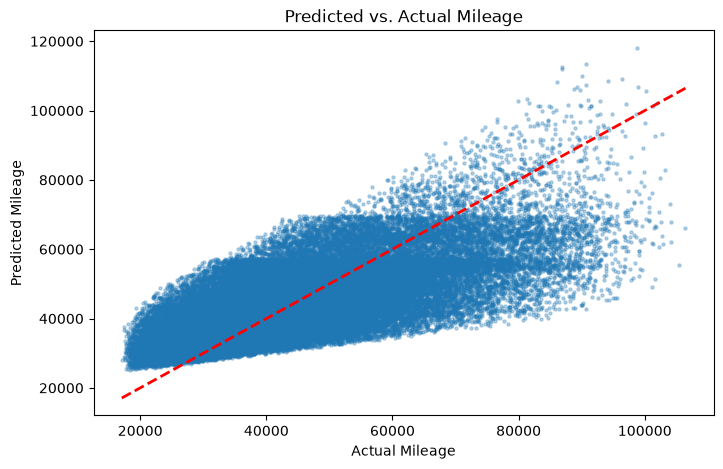

In [18]:
import matplotlib.pyplot as plt

# Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Mileage")
plt.ylabel("Predicted Mileage")
plt.title("Predicted vs. Actual Mileage")
plt.show()

## Model Results

**R² Score:** 0.486 (cross-validation mean: 0.483). The model explains approximately 49% of the variance in mileage at failure. The remaining 51% is influenced by factors not captured in this dataset (e.g. driving behavior, road conditions, maintenance).

**Coefficients:**

| Feature | Coefficient | Interpretation |
|---|---|---|
| Intercept | 9,904.54 | Baseline mileage at failure for a large engine |
| days | -0.18 | Older vehicles tend to fail at slightly lower mileage |
| fuel | 5,218.74 | Higher fuel consumption is associated with significantly higher mileage at failure |
| engine_medium | +7,749.40 | Medium engines fail ~7,750 km later than large engines |
| engine_small | +11,054.01 | Small engines fail ~11,050 km later than large engines |

**Recommendations for OEM1:**
- **Engine size has the strongest effect.** Small engines last significantly longer before failure than large engines (+11,054 km). OEM1 should investigate why large engines fail earlier and whether design or material differences cause this.
- **Fuel consumption** is positively correlated with mileage at failure. Vehicles with higher consumption tend to drive longer before a defect occurs. This could indicate that higher-performance vehicles are built more robustly.
- **Vehicle age** has a negligible effect (-0.18 km per day). Age alone is not a strong predictor of failure mileage.
- **Model limitation:** With R² = 0.49, the model captures only about half the variance. Additional variables (e.g. maintenance history, driving patterns) would be needed for more accurate predictions.